<a href="https://colab.research.google.com/github/rizwinmk/ICT_DSA_NOTES/blob/main/unsupervised_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
data=pd.read_csv('adult_dataset.csv')

In [ ]:
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [ ]:
data.shape

(48842, 15)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
data.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [ ]:
for col in data.columns:
    print(col, (data[col] == '?').sum())

age 0
workclass 1763
fnlwgt 0
education 0
education-num 0
marital-status 0
occupation 1758
relationship 0
race 0
sex 0
capital-gain 0
capital-loss 0
hours-per-week 0
native-country 555
income 0


In [ ]:
data.replace('?', np.nan, inplace=True)

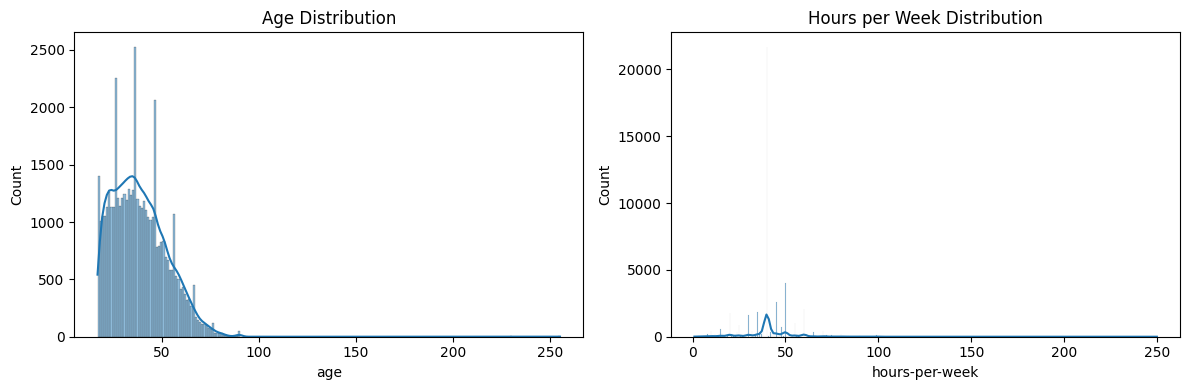

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(data['age'], kde=True)
plt.title("Age Distribution")

plt.subplot(1,2,2)
sns.histplot(data['hours-per-week'], kde=True)
plt.title("Hours per Week Distribution")

plt.tight_layout()
plt.show()

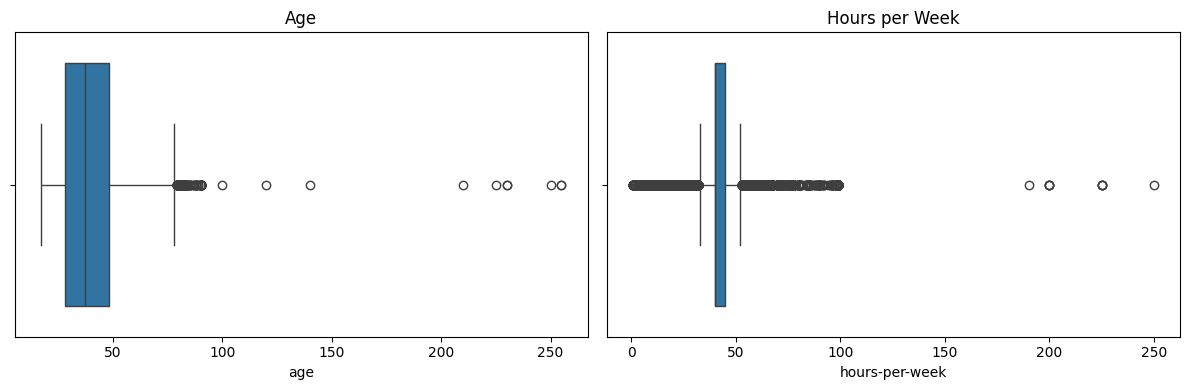

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(x=data['age'])
plt.title("Age")

plt.subplot(1,2,2)
sns.boxplot(x=data['hours-per-week'])
plt.title("Hours per Week")

plt.tight_layout()
plt.show()

In [ ]:
# Numerical columns
data['age'].fillna(data['age'].median(), inplace=True)
data['hours-per-week'].fillna(data['hours-per-week'].median(), inplace=True)

/tmp/ipykernel_5077/4237392615.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(), inplace=True)
/tmp/ipykernel_5077/4237392615.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
cat_cols = ['workclass', 'occupation', 'native-country']

for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_5077/3587052025.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# -------------------------------
# 1. Ordinal Encoding for Education
# -------------------------------
education_order = {
    'Preschool': 0,
    '1st-4th': 1,
    '5th-6th': 2,
    '7th-8th': 3,
    '9th': 4,
    '10th': 5,
    '11th': 6,
    '12th': 7,
    'HS-grad': 8,
    'Some-college': 9,
    'Assoc-voc': 10,
    'Assoc-acdm': 11,
    'Bachelors': 12,
    'Masters': 13,
    'Prof-school': 14,
    'Doctorate': 15
}

data['education'] = data['education'].map(education_order)

# -------------------------------
# 2. Binary Encoding for Sex
# -------------------------------
data['sex'] = data['sex'].map({'Female': 0, 'Male': 1})

# -------------------------------
# 3. Label Encode Income (for later comparison only)
# -------------------------------
income_encoder = LabelEncoder()
data['income'] = income_encoder.fit_transform(data['income'])

# -------------------------------
# 4. One-Hot Encode Nominal Features
# -------------------------------
nominal_cols = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'native-country'
]

data = pd.get_dummies(
    data,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)

# -------------------------------
# 5. Create Dataset for Clustering
# -------------------------------
cluster_df = data.drop(columns=['income'])

# Verify
print(cluster_df.head())
print(cluster_df.shape)

    age  fnlwgt  education  education-num  sex  capital-gain  capital-loss  \
0  39.0   77516         12             13    1          2174             0   
1  50.0   83311         12             13    1             0             0   
2  38.0  215646          8              9    1             0             0   
3  53.0  234721          6              7    1             0             0   
4  28.0  338409         12             13    0             0             0   

   hours-per-week  workclass_Local-gov  workclass_Never-worked  ...  \
0            40.0                    0                       0  ...   
1            13.0                    0                       0  ...   
2            40.0                    0                       0  ...   
3            40.0                    0                       0  ...   
4            40.0                    0                       0  ...   

   native-country_Portugal  native-country_Puerto-Rico  \
0                        0                    

In [ ]:
data.head()

,age,fnlwgt,education,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516,12,13,1,2174,0,40.0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,83311,12,13,1,0,0,13.0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38.0,215646,8,9,1,0,0,40.0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53.0,234721,6,7,1,0,0,40.0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,338409,12,13,0,0,0,40.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
num_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

In [ ]:
for col in num_cols:
    Q1 = cluster_df[col].quantile(0.25)
    Q3 = cluster_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = cluster_df[(cluster_df[col] < lower) | (cluster_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 364 outliers
fnlwgt: 1453 outliers
education-num: 1794 outliers
capital-gain: 4035 outliers
capital-loss: 2282 outliers
hours-per-week: 12838 outliers


In [ ]:
for col in num_cols:
    Q1 = cluster_df[col].quantile(0.25)
    Q3 = cluster_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    cluster_df[col] = cluster_df[col].clip(lower, upper)

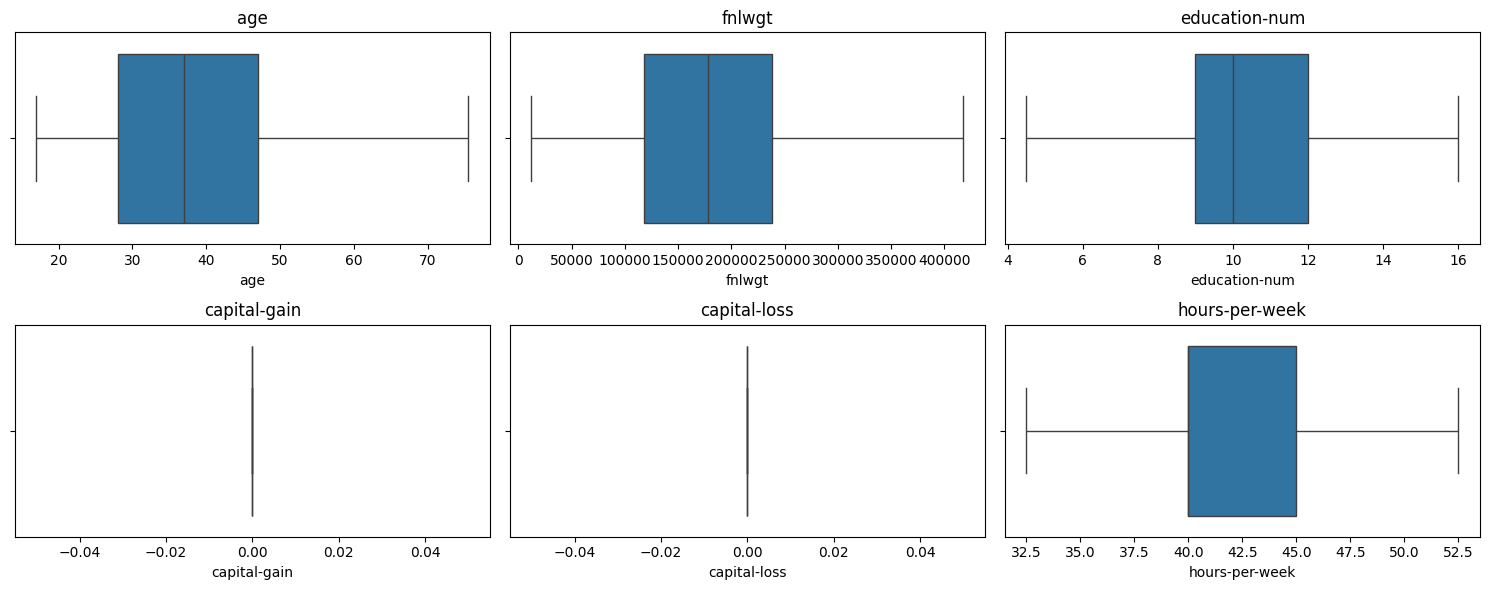

In [ ]:
plt.figure(figsize=(15,6))

for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(x=cluster_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Numerical columns to scale
num_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

# Create a copy of the dataset
cluster_scaled = cluster_df.copy()

# Apply StandardScaler only to numerical columns
scaler = StandardScaler()
cluster_scaled[num_cols] = scaler.fit_transform(cluster_scaled[num_cols])

# Verify
cluster_scaled.head()

,age,fnlwgt,education,education-num,sex,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.035311,-1.146097,12,1.171374,1,0.0,0.0,-0.187236,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.864184,-1.085307,12,1.171374,1,0.0,0.0,-1.430298,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-0.040041,0.302906,8,-0.456714,1,0.0,0.0,-0.187236,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1.090241,0.503005,6,-1.270758,1,0.0,0.0,-0.187236,0,0,...,0,0,0,0,0,0,0,1,0,0
4,-0.793562,1.590706,12,1.171374,0,0.0,0.0,-0.187236,0,0,...,0,0,0,0,0,0,0,0,0,0


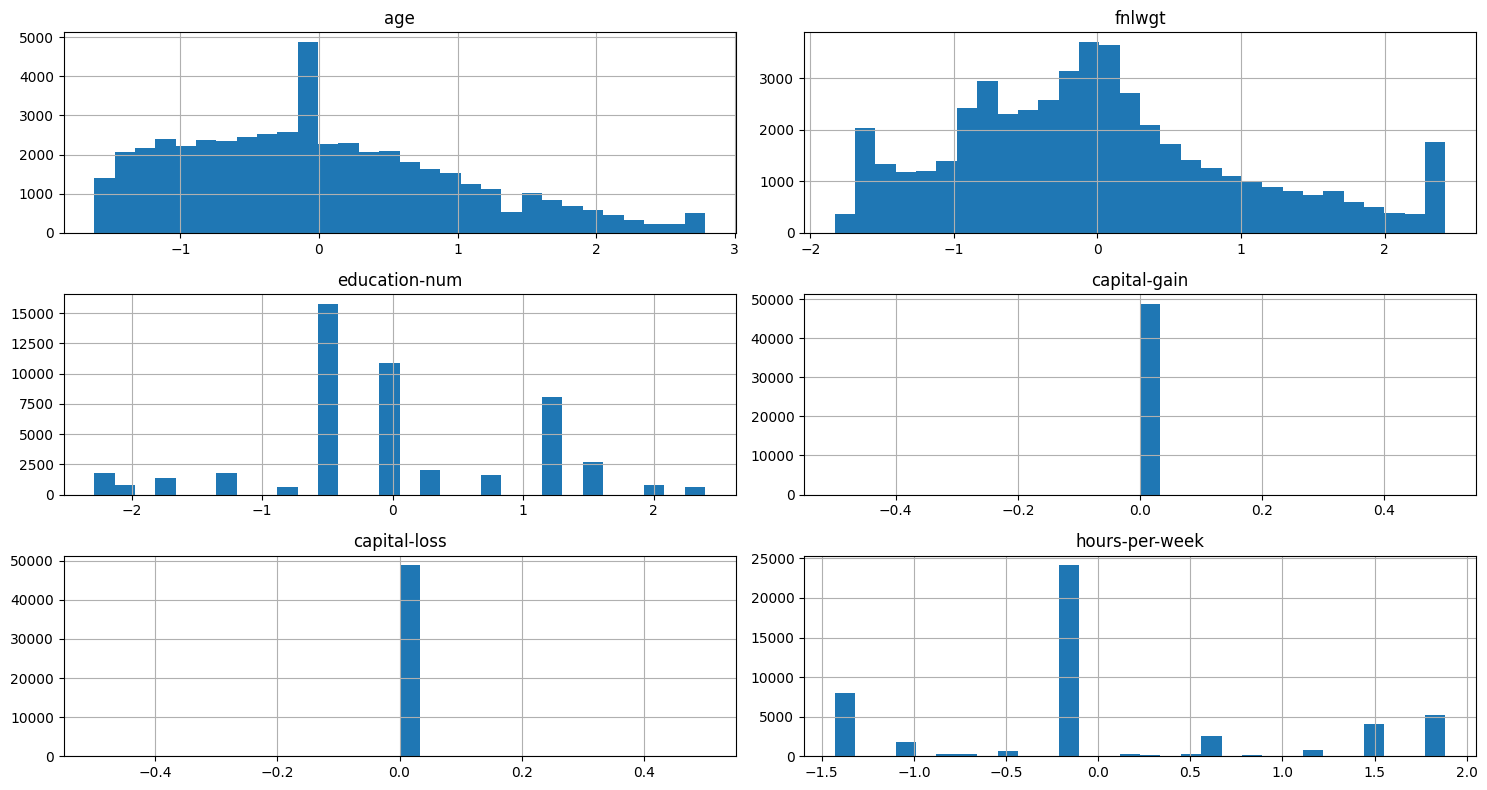

In [ ]:
num_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

cluster_scaled[num_cols].hist(figsize=(15,8), bins=30)
plt.tight_layout()
plt.show()

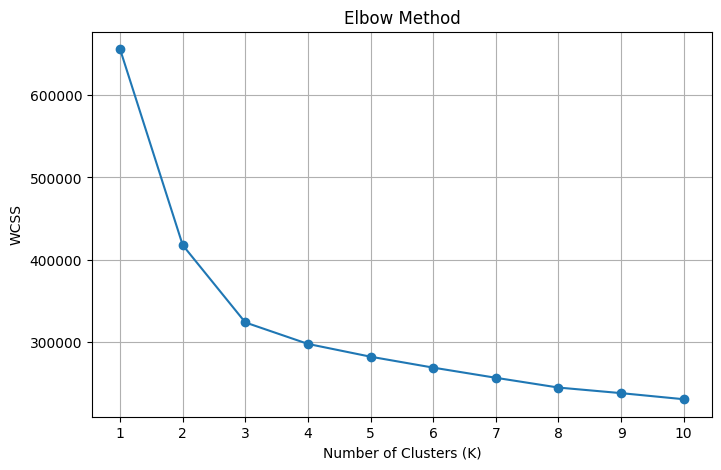

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

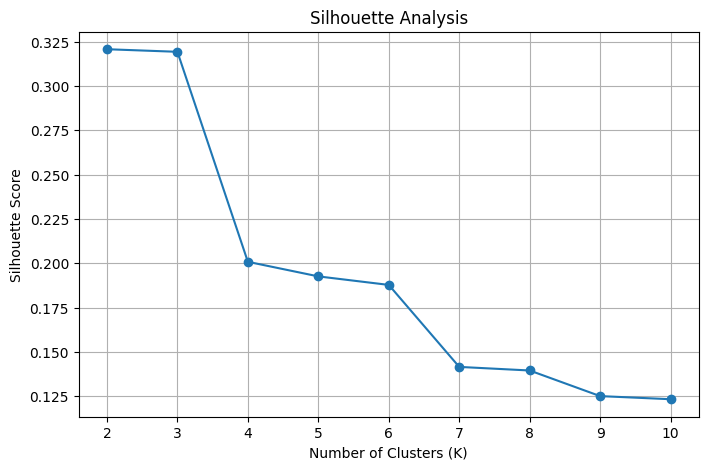

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_scaled)
    score = silhouette_score(cluster_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

cluster_scaled['Cluster'] = clusters


In [ ]:
cluster_scaled['Cluster'].value_counts()

,count
Cluster,
2,29380
1,13711
0,5751


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_scaled.drop(columns=['Cluster']),
                         cluster_scaled['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.3192698693908374


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(
    cluster_scaled.drop(columns=['Cluster'])
)

In [ ]:
pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = cluster_scaled['Cluster']

In [ ]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.57178737 0.09540424]
Total Explained Variance: 0.667191617082839


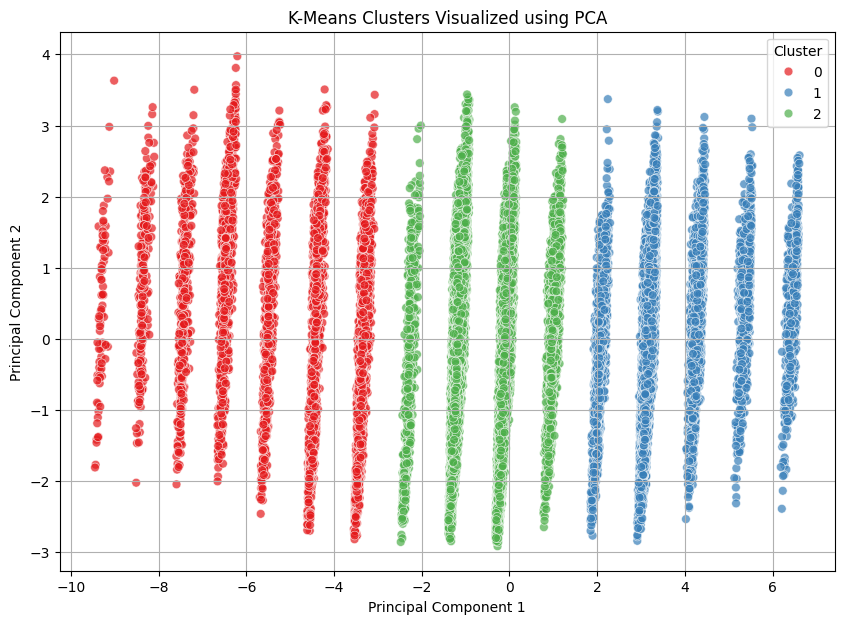

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=40,
    alpha=0.7
)

plt.title("K-Means Clusters Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

agg_labels = agg.fit_predict(pca_df[['PC1', 'PC2']])

from sklearn.metrics import silhouette_score

score = silhouette_score(
    pca_df[['PC1', 'PC2']],
    agg_labels
)

print("Agglomerative Silhouette Score:", score)

In [ ]:
pca_df['Agg_Cluster'] = agg_labels

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Agg_Cluster',
    palette='Set1',
    s=40
)

plt.title("Agglomerative Clustering (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

could not be completed as colab allocated memmory became full

